In [1]:
from pathlib import Path
import sqlite3
import pandas as pd

BASE_DIR = Path.cwd().parent
DB_PATH = BASE_DIR / "inventorydb.db"

conn = sqlite3.connect(DB_PATH)

In [2]:
vendor_df = pd.read_sql_query("SELECT * FROM vendor_invoice", conn)

vendor_df.head()

,vendornumber,vendorname,ponumber,invoicedate,podate,paydate,quantity,dollars,vendor_distance,vendor_rate,freight,Approval
0,1000,"Todd, Schultz and Stewart",11084,2024-08-30,2024-08-23,2024-09-21,22,141.46,405.813113,0.812572,60.75,Approved
1,1000,"Todd, Schultz and Stewart",11353,2025-04-14,2025-04-03,2025-05-06,100,6823.00,405.813113,0.812572,100.22,Pending
2,1000,"Todd, Schultz and Stewart",11531,2024-04-25,2024-04-15,2024-05-20,86,552.98,405.813113,0.812572,98.41,Approved
3,1000,"Todd, Schultz and Stewart",11580,2024-09-26,2024-09-13,2024-10-22,91,6208.93,405.813113,0.812572,70.59,Pending
4,1000,"Todd, Schultz and Stewart",11926,2024-06-24,2024-06-13,2024-07-12,59,3388.96,405.813113,0.812572,77.01,Approved


In [3]:
vendor_df.describe()

,vendornumber,ponumber,quantity,dollars,vendor_distance,vendor_rate,freight
count,49846.000000,49846.000000,49846.000000,49846.000000,49846.000000,49846.000000,49846.000000
mean,1048.511054,55065.141937,50.694098,2097.552682,498.151258,0.996847,83.628121
std,28.339629,26031.588190,29.076117,1766.336611,284.006355,0.117671,28.408428
min,1000.000000,10000.000000,1.000000,3.210000,55.246011,0.802781,5.490000
25%,1024.000000,32388.000000,26.000000,655.080000,225.611733,0.895825,62.710000
50%,1048.000000,55180.000000,51.000000,1607.225000,498.604179,0.998899,81.570000
75%,1072.000000,77760.750000,76.000000,3142.380000,745.394245,1.104648,102.370000
max,1099.000000,99997.000000,194.000000,10710.900000,987.542590,1.194260,243.450000


In [4]:
vendor_df.isnull().sum()

vendornumber       0
vendorname         0
ponumber           0
invoicedate        0
podate             0
paydate            0
quantity           0
dollars            0
vendor_distance    0
vendor_rate        0
freight            0
Approval           0
dtype: int64

In [5]:
vendor_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49846 entries, 0 to 49845
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   vendornumber     49846 non-null  int64  
 1   vendorname       49846 non-null  object 
 2   ponumber         49846 non-null  int64  
 3   invoicedate      49846 non-null  object 
 4   podate           49846 non-null  object 
 5   paydate          49846 non-null  object 
 6   quantity         49846 non-null  int64  
 7   dollars          49846 non-null  float64
 8   vendor_distance  49846 non-null  float64
 9   vendor_rate      49846 non-null  float64
 10  freight          49846 non-null  float64
 11  Approval         49846 non-null  object 
dtypes: float64(4), int64(3), object(5)
memory usage: 4.6+ MB


In [6]:
date_cols = ["invoicedate", "podate", "paydate"]

for col in date_cols:
    vendor_df[col] = pd.to_datetime(vendor_df[col])

### Exploratory Data Analysis

#### Relationship with target

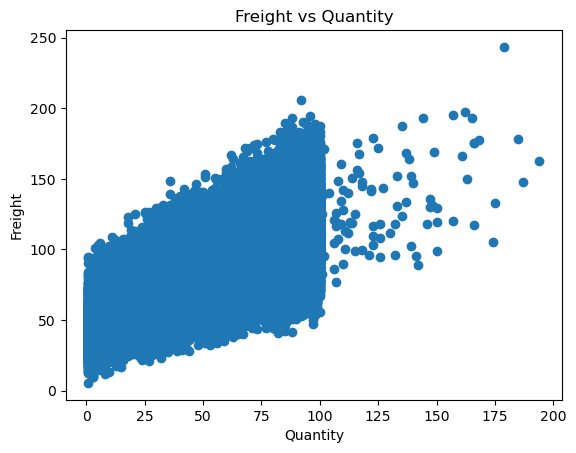

In [7]:
import matplotlib.pyplot as plt

plt.scatter(vendor_df['quantity'], vendor_df['freight'])
plt.xlabel('Quantity')
plt.ylabel('Freight')
plt.title('Freight vs Quantity')
plt.show()

Freight increases with quantity, with presence of outliers (very high freight)

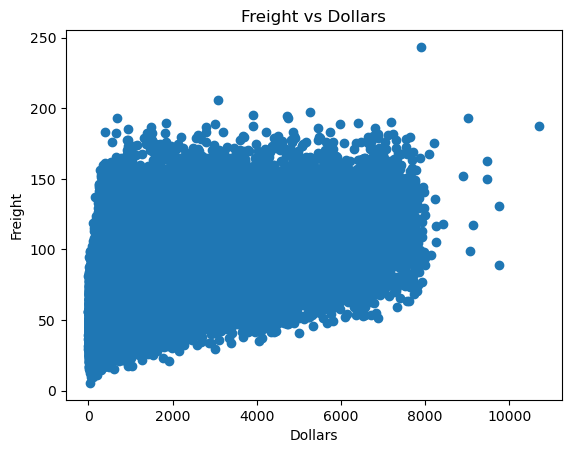

In [8]:
plt.scatter(vendor_df['dollars'], vendor_df['freight'])
plt.xlabel('Dollars')
plt.ylabel('Freight')
plt.title('Freight vs Dollars')
plt.show()

Non-linear pattern between freight and dollars, with presence of outliers

#### Correlation

In [9]:
vendor_df[['quantity', 'dollars', 'freight']].corr()

,quantity,dollars,freight
quantity,1.000000,0.680494,0.708081
dollars,0.680494,1.000000,0.490306
freight,0.708081,0.490306,1.000000


The strong correlation is indicative of  good predictive signal

### Feature Engineering

In [10]:
# Log Transformations to reduce skew
import numpy as np

vendor_df['log_quantity'] = np.log1p(vendor_df['quantity'])
vendor_df['log_dollars'] = np.log1p(vendor_df['dollars'])
vendor_df['log_freight'] = np.log1p(vendor_df['freight'])

In [11]:
# Order size category
vendor_df['order_size'] = pd.qcut(vendor_df['quantity'], q=4, labels=False)

In [12]:
# which vendors are cheaper per unit?

# Freight efficiency
vendor_df['freight_per_unit'] = vendor_df['freight'] / vendor_df['quantity']

vendor_eff = vendor_df.groupby('vendornumber')['freight_per_unit'].mean()
vendor_df['vendor_efficiency'] = vendor_df['vendornumber'].map(vendor_eff)

In [13]:
# Relative Order Size. Is this order big for this vendor?

vendor_df['relative_order_size'] = (vendor_df['quantity'] / vendor_df.groupby('vendornumber')['quantity'].transform('mean'))

In [14]:
# separate transport cost vs volume cost

vendor_df['freight_per_km'] = vendor_df['freight'] / vendor_df['vendor_distance']
vendor_df['quantity_per_km'] = vendor_df['quantity'] / vendor_df['vendor_distance']

In [15]:
# expensive vs cheap goods

vendor_df['dollars_per_unit'] = vendor_df['dollars'] / vendor_df['quantity']

In [16]:
# Time-based feature
vendor_df['delivery_days'] = (vendor_df['invoicedate'] - vendor_df['podate']).dt.days

In [17]:
# interaction features
vendor_df['qty_distance_interaction'] = vendor_df['quantity'] * vendor_df['vendor_distance']
vendor_df['qty_dollars_interaction'] = vendor_df['quantity'] * vendor_df['dollars']

### Feature Selection

In [18]:
features = ['quantity', 'dollars', 'delivery_days', 'vendor_distance', 'log_quantity', 'log_dollars', 'relative_order_size', 'quantity_per_km', 'dollars_per_unit', 'order_size', 'qty_distance_interaction', 'qty_dollars_interaction']
target = 'freight'

X = vendor_df[features]
y = vendor_df[target]

### Train-Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Model Training

#### Linear Regression

In [20]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

#### Decision Tree

In [21]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

#### Random Forest

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=8, random_state=42)

### Model Evaluation

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(model, name):
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    print(f"\n{name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2: {r2:.2f}")

evaluate(lr, "Linear Regression")
evaluate(dt, "Decision Tree")
evaluate(rf, "Random Forest")


Linear Regression
MAE: 13.20
RMSE: 16.73
R2: 0.66

Decision Tree
MAE: 13.50
RMSE: 17.04
R2: 0.64

Random Forest
MAE: 13.05
RMSE: 16.48
R2: 0.67


Random Forest slightly outperforms Linear Regression & Decision Tree.

### Feature Importance

In [24]:
importance = pd.Series(rf.feature_importances_, index=features)
importance.sort_values()

order_size                  0.000072
dollars                     0.001796
log_dollars                 0.001820
delivery_days               0.002800
dollars_per_unit            0.003162
qty_dollars_interaction     0.004132
quantity_per_km             0.006100
log_quantity                0.018210
quantity                    0.026162
vendor_distance             0.026703
relative_order_size         0.139591
qty_distance_interaction    0.769452
dtype: float64

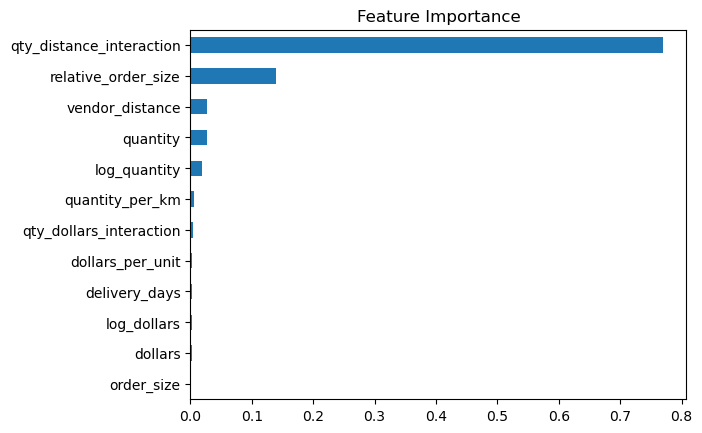

In [25]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=features)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

-  Economies of scale:
    *   Larger orders - lower freight per unit

### Retraining using the top features

In [26]:
top_features = ['qty_distance_interaction', 'relative_order_size', 'vendor_distance', 'quantity', 'log_quantity']

X_top = vendor_df[top_features]
y = vendor_df['freight']


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_top, y, test_size=0.2, random_state=42)


from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=8, random_state=42)

In [27]:
evaluate(rf, "Random Forest")


Random Forest
MAE: 13.02
RMSE: 16.44
R2: 0.67


The model is slightly better

### Prediction Visualization

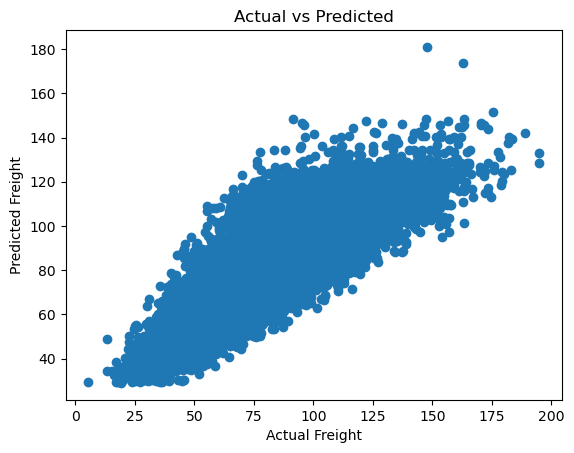

In [28]:
preds = rf.predict(X_test)

plt.scatter(y_test, preds)
plt.xlabel("Actual Freight")
plt.ylabel("Predicted Freight")
plt.title("Actual vs Predicted")
plt.show()

In [30]:
# Saving the model
MODEL_PATH = BASE_DIR / "artifacts"
MODEL_PATH.mkdir(exist_ok=True)

import joblib
joblib.dump(rf, MODEL_PATH / 'freight_predictor.pkl')

['C:\\Users\\Administrator\\Desktop\\Invoice-Intelligence\\artifacts\\freight_predictor.pkl']